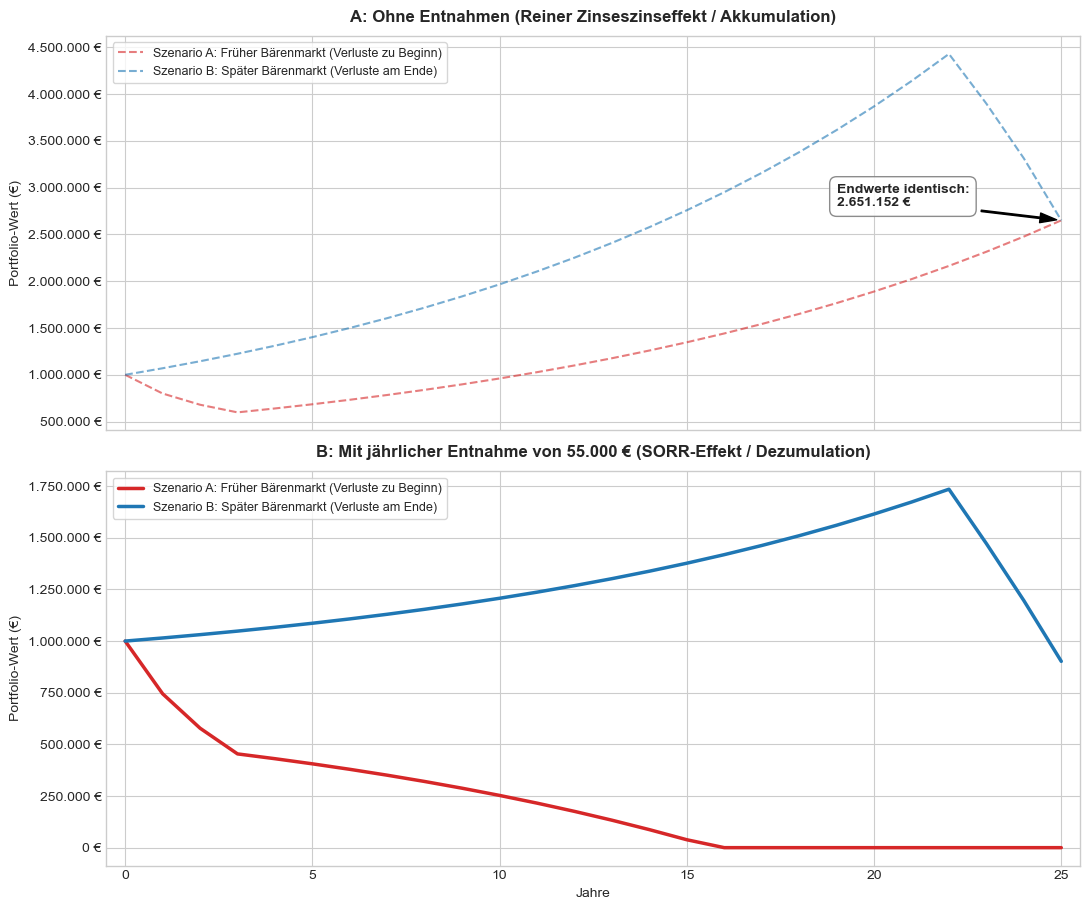

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1. Parameter für die Simulation
initial_capital = 1000000
annual_withdrawal = 55000  # Jährliche Entnahme
years = 25

# Festgelegtes Rendite-Set (Identisch für beide Szenarien: 22x Gewinn, 3x Verlust)
# Dies stellt sicher, dass die Durchschnittsrendite exakt gleich ist.
base_returns = [0.07] * 22 + [-0.20, -0.15, -0.12] 

# Szenario A: Die schlechten Jahre kommen zuerst (Bad Sequence)
ret_bad_start = sorted(base_returns)  

# Szenario B: Die guten Jahre kommen zuerst (Good Sequence)
ret_good_start = sorted(base_returns, reverse=True)  

def simulate_portfolio(initial, returns, withdrawal=0):
    balances = [initial]
    current_balance = initial
    for r in returns:
        # Erst wirkt die Marktrendite, dann erfolgt die Entnahme
        current_balance = (current_balance * (1 + r)) - withdrawal
        # Das Portfolio kann nicht unter 0 fallen
        balances.append(max(0, current_balance))
    return balances

# Durchführung der Simulationen
path_a_no_ext = simulate_portfolio(initial_capital, ret_bad_start, 0)
path_b_no_ext = simulate_portfolio(initial_capital, ret_good_start, 0)
path_a_ext = simulate_portfolio(initial_capital, ret_bad_start, annual_withdrawal)
path_b_ext = simulate_portfolio(initial_capital, ret_good_start, annual_withdrawal)

# 2. Erstellung der Grafik
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)
plt.style.use('seaborn-v0_8-whitegrid')

# Hilfsfunktion für die deutsche Währungsformatierung (1.000.000 € statt 1,000,000 $)
def euro_format(x, p):
    return f"{int(x):,}".replace(",", ".") + " €"

# --- OBERER PLOT: Ohne Entnahmen ---
ax1.plot(path_a_no_ext, color='#d62728', linestyle='--', alpha=0.6, label='Szenario A: Früher Bärenmarkt (Verluste zu Beginn)')
ax1.plot(path_b_no_ext, color='#1f77b4', linestyle='--', alpha=0.6, label='Szenario B: Später Bärenmarkt (Verluste am Ende)')
ax1.set_title('A: Ohne Entnahmen (Reiner Zinseszinseffekt / Akkumulation)', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Portfolio-Wert (€)', fontsize=10)

# Optimierte Annotation mit Hintergrundbox für bessere Lesbarkeit
ax1.annotate(f'Endwerte identisch:\n{path_a_no_ext[-1]:,.0f} €'.replace(',', '.'), 
             xy=(years, path_a_no_ext[-1]), 
             #xytext=(years-11, 3_800_000), # Position im Weißraum
             xytext=(years-6, 2_800_000), # Position im Weißraum
             fontsize=10,
             fontweight='bold',
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=7),
             bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='gray', alpha=0.9))

# --- UNTERER PLOT: Mit Entnahmen (SORR) ---
ax2.plot(path_a_ext, color='#d62728', linewidth=2.5, label='Szenario A: Früher Bärenmarkt (Verluste zu Beginn)')
ax2.plot(path_b_ext, color='#1f77b4', linewidth=2.5, label='Szenario B: Später Bärenmarkt (Verluste am Ende)')
ax2.set_title(f'B: Mit jährlicher Entnahme von {annual_withdrawal:,} € (SORR-Effekt / Dezumulation)'.replace(',', '.'), 
             fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel('Portfolio-Wert (€)', fontsize=10)
ax2.set_xlabel('Jahre', fontsize=10)

# --- Allgemeine Formatierung ---
for ax in [ax1, ax2]:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(euro_format))
    ax.legend(loc='upper left', frameon=True, fontsize=9)
    ax.set_xlim(-0.5, years + 0.5)

# Haupttitel
#plt.suptitle('Abbildung 1: Schematische Darstellung des SORR in der Entnahmephase', 
             #fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Grafik speichern (optional)
plt.savefig('../../assets/SORR_schema.png', dpi=300)

plt.show()